<a href="https://colab.research.google.com/github/jannahashraf/yelp-analysis/blob/Random_Forest_%2B_XGBoost-model/Random_Forest_%2B_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import pickle
import time

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

import lightgbm as lgb

import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(
    '/content/drive/MyDrive/part-00000-5d7d137c-d451-4b65-b9c2-3c3d0bbcd7f8-c000.csv',
    on_bad_lines='skip',
    low_memory=False
)

print("Shape:", df.shape)
df.head()

Shape: (569937, 25)


,user_id,business_id,review_id,review_stars,date,text,useful,funny,cool,clean_text,...,state,business_stars,review_count,categories,is_open,user_review_count,yelping_since,user_useful,user_funny,user_cool
0,--RJK834fiQXm21VpJp_nw,aIoUwpy5ZFQXUDxWMnMZ4Q,QPF7spAqCc-D81GeXcfIoQ,1.0,2019-08-25 23:17:52,There are new owners here. Way over priced and...,0,0,0,there are new owners here way over priced and ...,...,FL,3.5,146,"Seafood, Diners, Beer, Wine & Spirits, Comfort...",1,1,2018-02-04 20:34:16,0,0,0
1,--UhENQdbuWEh0mU5weIEg,K_s-9Wd6vXSfnxYFzhE0Kw,dghJt1TSuyFkmLdduTThyA,5.0,2017-08-06 02:42:02,"When im first arrived in Phila, a friend of mi...",0,1,1,when im first arrived in phila a friend of min...,...,PA,4.5,157,"Sushi Bars, Restaurants",1,1,2017-06-19 18:37:56,0,1,1
2,--cxdcv_b9uhAKsKTlyC3Q,oD3zBLplcYefdMHo54CJkQ,VNT1ymOYUuWC-qxdIeZxRw,4.0,2019-11-01 22:04:32,This is definitely one of my favorite indoor f...,0,0,0,this is definitely one of my favorite indoor f...,...,PA,4.0,29,"Fruits & Veggies, Seafood Markets, Specialty F...",1,4,2014-02-08 01:13:06,1,0,0
3,--z9XJZF0T2r7aIsZ_wBew,N2i1U4Z6GHEw9V02N2u6JA,aISJyFeAI1bSqhl1x0PBLg,5.0,2016-02-23 00:30:02,This is a great little boutique hotel! There i...,0,0,0,this is a great little boutique hotel there is...,...,FL,4.5,265,"Event Planning & Services, Hotels & Travel, Ho...",1,8,2010-07-12 16:55:32,5,0,3
4,--z9XJZF0T2r7aIsZ_wBew,B2Tuf5M1wQhdwAKnD-w7Yw,sIJrwL2ygPlAkcTGh4evSQ,5.0,2015-10-24 02:15:20,"This was so fun! The ride was awesome, we got ...",0,0,0,this was so fun the ride was awesome we got to...,...,LA,5.0,286,"Tours, Active Life, Bus Tours, Hotels & Travel...",1,8,2010-07-12 16:55:32,5,0,3


In [7]:
num_cols = [
    'review_stars',
    'useful',
    'funny',
    'cool',
    'word_count',
    'business_stars',
    'review_count',
    'is_open',
    'user_review_count',
    'user_useful',
    'user_funny',
    'user_cool'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric conversion done.")

Numeric conversion done.


In [8]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['yelping_since'] = pd.to_datetime(df['yelping_since'], errors='coerce')

print("Date conversion done.")

Date conversion done.


In [9]:
def label_fake(row):
    score = 0

    if row['user_review_count'] <= 2:
        score += 2

    if row['review_stars'] in [1.0, 5.0]:
        score += 1

    if row['word_count'] <= 10:
        score += 2

    if row['useful'] == 0 and row['funny'] == 0 and row['cool'] == 0:
        score += 1

    if pd.notna(row['review_stars']) and pd.notna(row['business_stars']):
        if abs(row['review_stars'] - row['business_stars']) >= 2:
            score += 1

    if row['user_useful'] == 0 and row['user_funny'] == 0 and row['user_cool'] == 0:
        score += 1

    return 1 if score >= 4 else 0

df['is_fake'] = df.apply(label_fake, axis=1)

print(df['is_fake'].value_counts())
print(f"Fake Ratio: {df['is_fake'].mean():.2%}")

is_fake
0    523264
1     46673
Name: count, dtype: int64
Fake Ratio: 8.19%


In [10]:
df = df[df['review_stars'].between(1, 5)]
df = df[df['business_stars'].between(1, 5)]
df = df[df['is_open'].isin([0, 1])]
df = df[df['word_count'] < 2000]

df = df.dropna(subset=['clean_text', 'is_fake'])

print("Clean shape:", df.shape)

Clean shape: (453215, 26)


In [11]:
df['account_age_days'] = (
    df['date'] - df['yelping_since']
).dt.days

print("Feature engineering complete.")

Feature engineering complete.


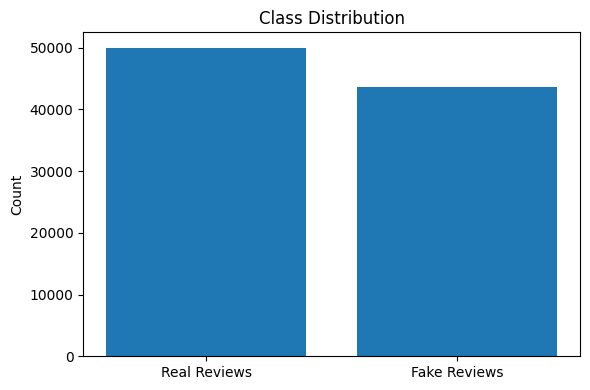

In [25]:
import matplotlib.pyplot as plt

class_counts = df['is_fake'].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    ['Real Reviews', 'Fake Reviews'],
    class_counts.values
)

plt.title("Class Distribution")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

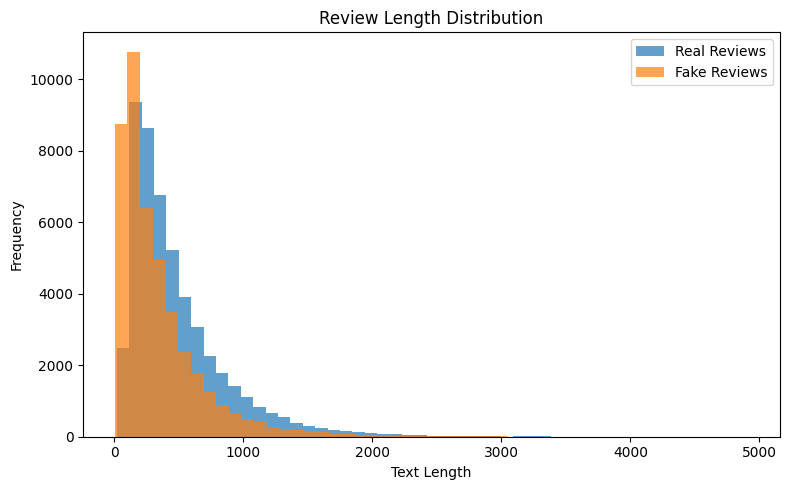

In [26]:
df['text_length'] = df['clean_text'].astype(str).apply(len)

plt.figure(figsize=(8, 5))

plt.hist(
    df[df['is_fake'] == 0]['text_length'],
    bins=50,
    alpha=0.7,
    label='Real Reviews'
)

plt.hist(
    df[df['is_fake'] == 1]['text_length'],
    bins=50,
    alpha=0.7,
    label='Fake Reviews'
)

plt.title("Review Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

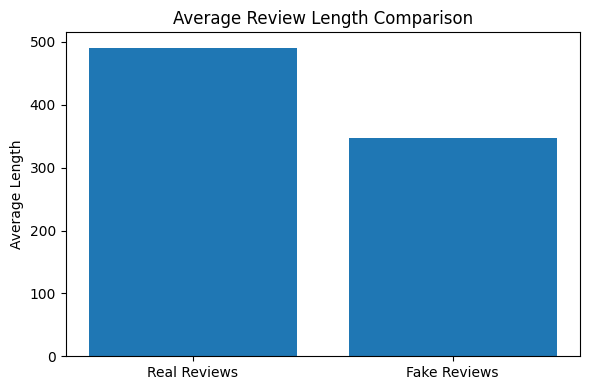

In [30]:
avg_lengths = df.groupby('is_fake')['text_length'].mean()

plt.figure(figsize=(6, 4))

plt.bar(
    ['Real Reviews', 'Fake Reviews'],
    avg_lengths.values
)

plt.ylabel("Average Length")
plt.title("Average Review Length Comparison")

plt.tight_layout()
plt.show()

In [12]:
df = df.groupby('is_fake', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50000), random_state=42)
).reset_index(drop=True)

print("Balanced shape:", df.shape)
print(df['is_fake'].value_counts())

/tmp/ipykernel_18163/291974215.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('is_fake', group_keys=False).apply(


Balanced shape: (93579, 27)
is_fake
0    50000
1    43579
Name: count, dtype: int64


In [13]:
SAFE_TABULAR_COLS = [
    'review_count',
    'is_open',
    'account_age_days'
]

text = df['clean_text'].fillna('').values
X_tab = df[SAFE_TABULAR_COLS].fillna(0).values
y = df['is_fake'].values

print("Prepared safe features.")

Prepared safe features.


In [14]:
# First split train+temp and test
text_train, text_temp, X_tab_train, X_tab_temp, y_train, y_temp = train_test_split(
    text,
    X_tab,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split temp into validation and test
text_val, text_test, X_tab_val, X_tab_test, y_val, y_test = train_test_split(
    text_temp,
    X_tab_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(y_train))
print("Validation:", len(y_val))
print("Test:", len(y_test))

Train: 65505
Validation: 14037
Test: 14037


In [15]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)

# Fit ONLY on training data
X_text_train = tfidf.fit_transform(text_train)

# Transform validation and test
X_text_val = tfidf.transform(text_val)
X_text_test = tfidf.transform(text_test)

print("TF-IDF complete.")

TF-IDF complete.


In [16]:
X_train = hstack([
    X_text_train,
    csr_matrix(X_tab_train)
])

X_val = hstack([
    X_text_val,
    csr_matrix(X_tab_val)
])

X_test = hstack([
    X_text_test,
    csr_matrix(X_tab_test)
])

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (65505, 50003)
Validation shape: (14037, 50003)
Test shape: (14037, 50003)


In [17]:
class TimedCallback:
    def __init__(self):
        self.start = time.time()
        self.last = time.time()

    def __call__(self, env):
        now = time.time()

        elapsed = now - self.start
        since_last = now - self.last

        self.last = now

        iteration = env.iteration
        score = env.evaluation_result_list[0][2]

        print(
            f"[{iteration:>4}] "
            f"loss: {score:.5f} | "
            f"elapsed: {elapsed:.1f}s | "
            f"last round: {since_last:.1f}s"
        )

timed_cb = TimedCallback()

In [18]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

print("🚀 Training started...")

start = time.time()

model.fit(
    X_train,
    y_train,

    eval_set=[(X_val, y_val)],

    callbacks=[
        lgb.early_stopping(30),
        lgb.log_evaluation(10),
        timed_cb
    ]
)

total = time.time() - start

print(f"\n✅ Training done in {total:.1f}s")

🚀 Training started...
[   0] loss: 0.68343 | elapsed: 119.9s | last round: 119.9s
Training until validation scores don't improve for 30 rounds
[   1] loss: 0.67469 | elapsed: 121.2s | last round: 1.3s
[   2] loss: 0.66650 | elapsed: 122.5s | last round: 1.3s
[   3] loss: 0.65911 | elapsed: 124.9s | last round: 2.4s
[   4] loss: 0.65215 | elapsed: 127.1s | last round: 2.3s
[   5] loss: 0.64588 | elapsed: 128.4s | last round: 1.3s
[   6] loss: 0.63987 | elapsed: 129.6s | last round: 1.2s
[   7] loss: 0.63449 | elapsed: 130.9s | last round: 1.3s
[   8] loss: 0.62957 | elapsed: 132.2s | last round: 1.3s
[   9] loss: 0.62492 | elapsed: 133.4s | last round: 1.3s
[10]	valid_0's binary_logloss: 0.624919
[  10] loss: 0.62057 | elapsed: 134.7s | last round: 1.2s
[  11] loss: 0.61653 | elapsed: 135.9s | last round: 1.2s
[  12] loss: 0.61273 | elapsed: 137.1s | last round: 1.3s
[  13] loss: 0.60904 | elapsed: 139.4s | last round: 2.3s
[  14] loss: 0.60570 | elapsed: 142.0s | last round: 2.5s
[  15

In [19]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, preds))

auc = roc_auc_score(y_test, probs)

print(f"\nAUC Score: {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Classification Report ===
              precision    recall  f1-score   support

           0       0.77      0.73      0.75      7500
           1       0.71      0.74      0.72      6537

    accuracy                           0.74     14037
   macro avg       0.74      0.74      0.74     14037
weighted avg       0.74      0.74      0.74     14037


AUC Score: 0.8170


In [20]:
cm = confusion_matrix(y_test, preds)

print(cm)

[[5502 1998]
 [1690 4847]]


In [21]:
with open('/content/drive/MyDrive/lgbm_fake_review_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('/content/drive/MyDrive/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model and TF-IDF saved.")

✅ Model and TF-IDF saved.


In [22]:
results_df = pd.DataFrame({
    'actual_target': y_test,
    'predicted_target': preds,
    'prediction_probability': probs
})

results_df.to_csv(
    '/content/drive/MyDrive/fake_review_predictions.csv',
    index=False
)

print("✅ Prediction CSV saved successfully!")
print(results_df.head())

✅ Prediction CSV saved successfully!
   actual_target  predicted_target  prediction_probability
0              0                 1                0.639517
1              0                 0                0.329650
2              0                 0                0.228166
3              1                 1                0.825535
4              0                 0                0.278594


In [23]:
report_df = pd.DataFrame(
    classification_report(
        y_test,
        preds,
        output_dict=True
    )
)

report_df.to_csv(
    '/content/drive/MyDrive/lgbm_results.csv'
)

print("✅ Results CSV saved.")

✅ Results CSV saved.


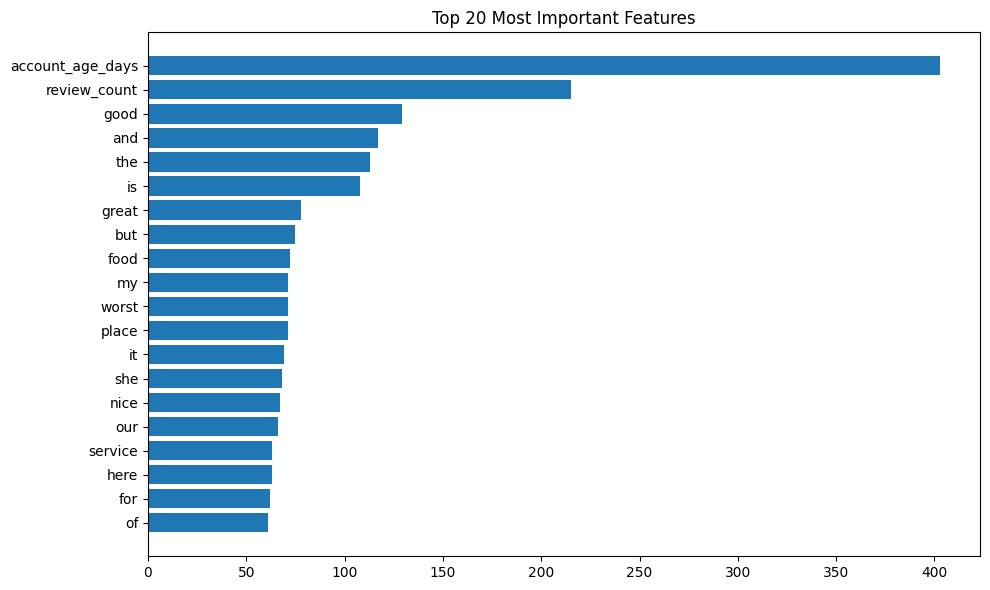

In [24]:
tfidf_features = tfidf.get_feature_names_out().tolist()

all_features = tfidf_features + SAFE_TABULAR_COLS

importance = model.feature_importances_

indices = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10, 6))

plt.barh(
    [all_features[i] for i in indices][::-1],
    importance[indices][::-1]
)

plt.title("Top 20 Most Important Features")

plt.tight_layout()

plt.show()

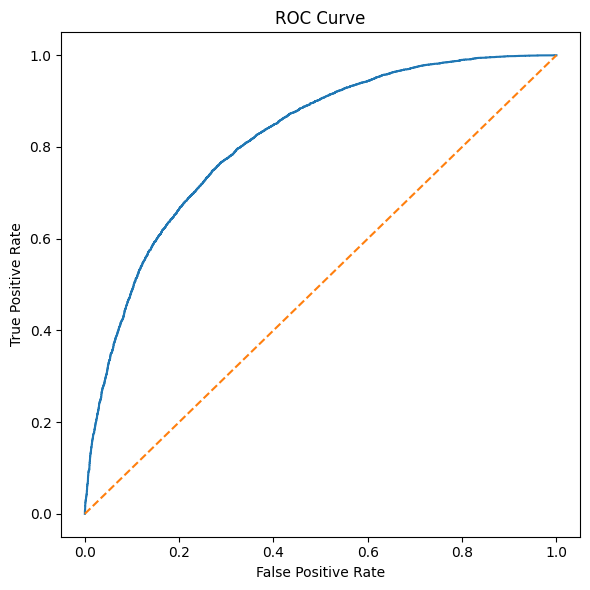

In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.tight_layout()
plt.show()

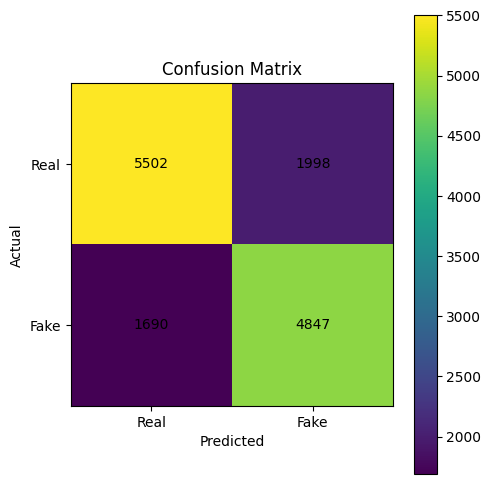

In [29]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5, 5))

plt.imshow(cm)

plt.xticks([0, 1], ['Real', 'Fake'])
plt.yticks([0, 1], ['Real', 'Fake'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()

plt.tight_layout()
plt.show()